# SIT307 11.1HD – Machine Learning Research


## The Stacking-Based Ensemble Technique for Heart Disease Prediction is reconstructed.
This notebook implements the machine learning methodology outlined in the chosen research paper and tests the performance of each of the classifiers as well as the stacking ensemble.

In [1]:
import pandas as pb
import numpy as np

## Dataset Loading and Initial Inspection

In [2]:
df = pb.read_csv("heart.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (1025, 14)

Column names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


### Data Quality Check

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [5]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [6]:
print("Number of duplicate rows:" , df.duplicated().sum())

Number of duplicate rows: 723


In [7]:
print("Target distribution:")
print(df["target"].value_counts())

Target distribution:
target
1    526
0    499
Name: count, dtype: int64


## Data Preparation

In [9]:
X = df.drop("target", axis=1)
y = df["target"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1025, 13)
Target shape: (1025,)


In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (820, 13)
Testing features: (205, 13)
Training target: (820,)
Testing target: (205,)


### Feature Scaling

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (820, 13)
Scaled testing shape: (205, 13)


## Individual Classifier Models

### Logistic Regression

In [14]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42)

lr_model.fit(X_train_scaled, y_train)

lr_predictions = lr_model.predict(X_test_scaled)

### Model Evaluation

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(y_test, predictions, probabilities):
    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    auc = roc_auc_score(y_test, probabilities)

    print("Accuracy:", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall:", round(recall, 4))
    print("F1 Score:", round(f1, 4))
    print("AUC:", round(auc, 4))

In [16]:
lr_probabilities = lr_model.predict_proba(X_test_scaled)[:, 1]

evaluate_model(y_test, lr_predictions, lr_probabilities)

Accuracy: 0.8098
Precision: 0.7619
Recall: 0.9143
F1 Score: 0.8312
AUC: 0.9298


### Decision Tree

In [17]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)
dt_probabilities = dt_model.predict_proba(X_test)[:, 1]

evaluate_model(y_test, dt_predictions, dt_probabilities)

Accuracy: 0.9854
Precision: 1.0
Recall: 0.9714
F1 Score: 0.9855
AUC: 0.9857


### Random Forest

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)
rf_probabilities = rf_model.predict_proba(X_test)[:, 1]

evaluate_model(y_test, rf_predictions, rf_probabilities)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
AUC: 1.0


### Naive Bayes

In [19]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

nb_model.fit(X_train_scaled, y_train)

nb_predictions = nb_model.predict(X_test_scaled)
nb_probabilities = nb_model.predict_proba(X_test_scaled)[:, 1]

evaluate_model(y_test, nb_predictions, nb_probabilities)

Accuracy: 0.8293
Precision: 0.807
Recall: 0.8762
F1 Score: 0.8402
AUC: 0.9043


### K-Nearest Neighbours

In [20]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()

knn_model.fit(X_train_scaled, y_train)

knn_predictions = knn_model.predict(X_test_scaled)
knn_probabilities = knn_model.predict_proba(X_test_scaled)[:, 1]

evaluate_model(y_test, knn_predictions, knn_probabilities)

Accuracy: 0.8634
Precision: 0.8738
Recall: 0.8571
F1 Score: 0.8654
AUC: 0.9629


### XGBoost

In [21]:
from xgboost import XGBClassifier

In [22]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

xgb_predictions = xgb_model.predict(X_test)
xgb_probabilities = xgb_model.predict_proba(X_test)[:, 1]

evaluate_model(y_test, xgb_predictions, xgb_probabilities)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
AUC: 1.0


## Individual Model Results

In [23]:
results = pb.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Naive Bayes",
        "KNN",
        "XGBoost"
    ],
    "Accuracy": [0.8098, 0.9854, 1.0000, 0.8293, 0.8634, 1.0000],
    "Precision": [0.7619, 1.0000, 1.0000, 0.8070, 0.8738, 1.0000],
    "Recall": [0.9143, 0.9714, 1.0000, 0.8762, 0.8571, 1.0000],
    "F1 Score": [0.8312, 0.9855, 1.0000, 0.8402, 0.8654, 1.0000],
    "AUC": [0.9298, 0.9857, 1.0000, 0.9043, 0.9629, 1.0000]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,0.8098,0.7619,0.9143,0.8312,0.9298
1,Decision Tree,0.9854,1.0000,0.9714,0.9855,0.9857
2,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000
3,Naive Bayes,0.8293,0.8070,0.8762,0.8402,0.9043
4,KNN,0.8634,0.8738,0.8571,0.8654,0.9629
5,XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000


## Stacking Ensemble Model

The six individual classifiers are combined using a 5-fold stacking approach.

In [24]:
from sklearn.ensemble import StackingClassifier
base_models = [
    ("lr", LogisticRegression(random_state=42)),
    ("dt", DecisionTreeClassifier(random_state=42)),
    ("rf", RandomForestClassifier(random_state=42)),
    ("nb", GaussianNB()),
    ("knn", KNeighborsClassifier()),
    ("xgb", XGBClassifier(random_state=42, eval_metric="logloss"))
]

meta_model = LogisticRegression(random_state=42)

stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5
)


In [25]:
stacking_model.fit(X_train_scaled, y_train)

stack_predictions = stacking_model.predict(X_test_scaled)
stack_probabilities = stacking_model.predict_proba(X_test_scaled)[:, 1]

evaluate_model(y_test, stack_predictions, stack_probabilities)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
AUC: 1.0


### Stacking Confusion Matrix

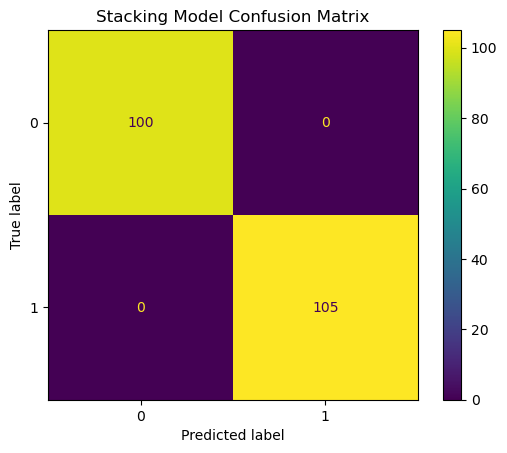

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    stack_predictions
)

plt.title("Stacking Model Confusion Matrix")
plt.show()

### Stacking ROC Curve

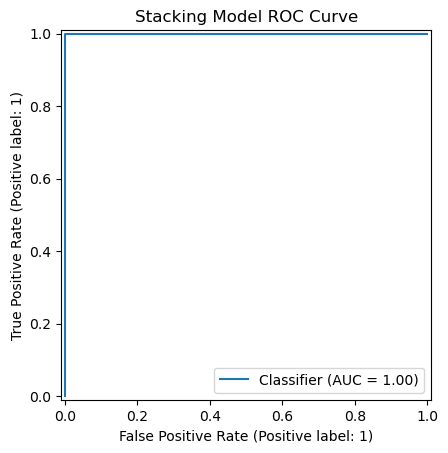

In [29]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    stack_probabilities
)

plt.title("Stacking Model ROC Curve")
plt.show()

## Comparison with the Research Paper

In [30]:
comparison = pb.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Naive Bayes",
        "KNN",
        "XGBoost",
        "Stacking"
    ],
    "Paper Accuracy": [
        0.8439,
        0.9268,
        0.9268,
        0.8439,
        0.8585,
        0.9073,
        0.9853
    ],
    "Reproduced Accuracy": [
        0.8098,
        0.9854,
        1.0000,
        0.8293,
        0.8634,
        1.0000,
        1.0000
    ]
})

comparison["Difference"] = (
    comparison["Reproduced Accuracy"] - comparison["Paper Accuracy"]
)

comparison.round(4)

,Model,Paper Accuracy,Reproduced Accuracy,Difference
0,Logistic Regression,0.8439,0.8098,-0.0341
1,Decision Tree,0.9268,0.9854,0.0586
2,Random Forest,0.9268,1.0000,0.0732
3,Naive Bayes,0.8439,0.8293,-0.0146
4,KNN,0.8585,0.8634,0.0049
5,XGBoost,0.9073,1.0000,0.0927
6,Stacking,0.9853,1.0000,0.0147


### Duplicate Data Investigation

In [31]:
df_unique = df.drop_duplicates()

print("Original dataset:", df.shape)
print("After removing duplicates:", df_unique.shape)
print("Duplicates removed:", df.shape[0] - df_unique.shape[0])

Original dataset: (1025, 14)
After removing duplicates: (302, 14)
Duplicates removed: 723


In [32]:
X_unique = df_unique.drop("target", axis=1)
y_unique = df_unique["target"]

X_train_u, X_test_u, y_train_u, y_test_u = train_test_split(
    X_unique,
    y_unique,
    test_size=0.20,
    random_state=42,
    stratify=y_unique
)

print("Unique training set:", X_train_u.shape)
print("Unique testing set:", X_test_u.shape)

Unique training set: (241, 13)
Unique testing set: (61, 13)


In [33]:
dt_unique = DecisionTreeClassifier(random_state=42)
rf_unique = RandomForestClassifier(random_state=42)
xgb_unique = XGBClassifier(random_state=42, eval_metric="logloss")

models_unique = {
    "Decision Tree": dt_unique,
    "Random Forest": rf_unique,
    "XGBoost": xgb_unique
}

for name, model in models_unique.items():
    model.fit(X_train_u, y_train_u)
    
    predictions = model.predict(X_test_u)
    accuracy = accuracy_score(y_test_u, predictions)
    
    print(name, "Accuracy:", round(accuracy, 4))

Decision Tree Accuracy: 0.8033
Random Forest Accuracy: 0.7541
XGBoost Accuracy: 0.7213


### Effect of Duplicate Removal

In [34]:
duplicate_comparison = pb.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "XGBoost"],
    "With Duplicates": [0.9854, 1.0000, 1.0000],
    "Without Duplicates": [0.8033, 0.7541, 0.7213]
})

duplicate_comparison["Accuracy Drop"] = (
    duplicate_comparison["With Duplicates"]
    - duplicate_comparison["Without Duplicates"]
)

duplicate_comparison.round(4)

,Model,With Duplicates,Without Duplicates,Accuracy Drop
0,Decision Tree,0.9854,0.8033,0.1821
1,Random Forest,1.0000,0.7541,0.2459
2,XGBoost,1.0000,0.7213,0.2787


# Part 2 – Proposed Machine Learning Solution

## Duplicate-Aware Experimental Approach

### Data Preparation for the Proposed Approach

In [35]:
X_proposed = df_unique.drop("target", axis=1)
y_proposed = df_unique["target"]

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_proposed,
    y_proposed,
    test_size=0.20,
    random_state=42,
    stratify=y_proposed
)

print("Training set:", X_train_p.shape)
print("Testing set:", X_test_p.shape)

Training set: (241, 13)
Testing set: (61, 13)


### Feature Scaling

In [36]:
scaler_p = StandardScaler()

X_train_p_scaled = scaler_p.fit_transform(X_train_p)
X_test_p_scaled = scaler_p.transform(X_test_p)

print("Scaled training set:", X_train_p_scaled.shape)
print("Scaled testing set:", X_test_p_scaled.shape)

Scaled training set: (241, 13)
Scaled testing set: (61, 13)


### Duplicate-Aware Stacking Model

In [37]:
base_models_p = [
    ("lr", LogisticRegression(random_state=42)),
    ("dt", DecisionTreeClassifier(random_state=42)),
    ("rf", RandomForestClassifier(random_state=42)),
    ("nb", GaussianNB()),
    ("knn", KNeighborsClassifier()),
    ("xgb", XGBClassifier(random_state=42, eval_metric="logloss"))
]

meta_model_p = LogisticRegression(random_state=42)

stacking_model_p = StackingClassifier(
    estimators=base_models_p,
    final_estimator=meta_model_p,
    cv=5
)

In [38]:
stacking_model_p.fit(X_train_p_scaled, y_train_p)

stack_predictions_p = stacking_model_p.predict(X_test_p_scaled)
stack_probabilities_p = stacking_model_p.predict_proba(X_test_p_scaled)[:, 1]

evaluate_model(
    y_test_p,
    stack_predictions_p,
    stack_probabilities_p
)

Accuracy: 0.7541
Precision: 0.7647
Recall: 0.7879
F1 Score: 0.7761
AUC: 0.868


### Evaluation of the Proposed Model

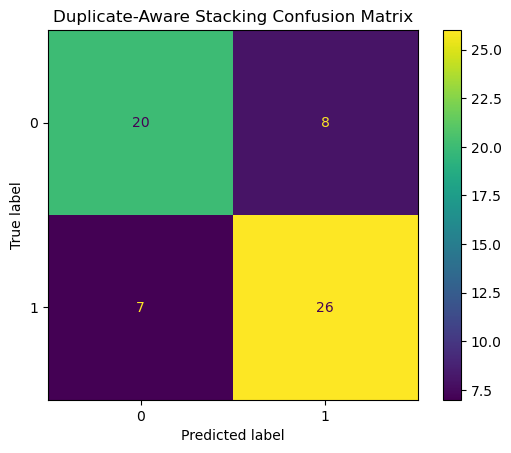

In [39]:
ConfusionMatrixDisplay.from_predictions(
    y_test_p,
    stack_predictions_p
)

plt.title("Duplicate-Aware Stacking Confusion Matrix")
plt.show()

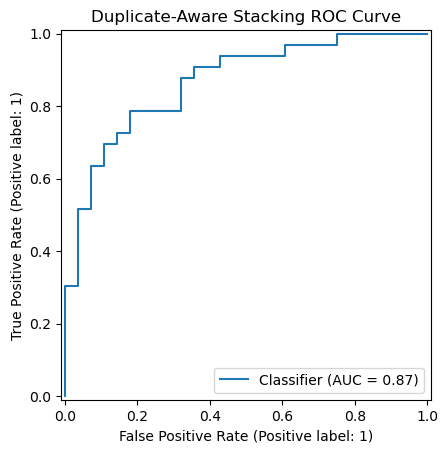

In [40]:
RocCurveDisplay.from_predictions(
    y_test_p,
    stack_probabilities_p
)

plt.title("Duplicate-Aware Stacking ROC Curve")
plt.show()

### Comparison of Stacking Results

In [41]:
stacking_comparison = pb.DataFrame({
    "Approach": [
        "Original Paper",
        "Part 1 Reproduction",
        "Part 2 Duplicate-Aware"
    ],
    "Accuracy": [0.9853, 1.0000, 0.7541],
    "Precision": [1.0000, 1.0000, 0.7647],
    "Recall": [0.9727, 1.0000, 0.7879],
    "F1 Score": [0.9861, 1.0000, 0.7761],
    "AUC": [0.9880, 1.0000, 0.8680]
})

stacking_comparison

,Approach,Accuracy,Precision,Recall,F1 Score,AUC
0,Original Paper,0.9853,1.0000,0.9727,0.9861,0.988
1,Part 1 Reproduction,1.0000,1.0000,1.0000,1.0000,1.000
2,Part 2 Duplicate-Aware,0.7541,0.7647,0.7879,0.7761,0.868


### Interpretation

The Part 1 stacking model was successful with 100% accuracy, although there were 723 duplicate rows in the dataset. There were 302 unique records after the duplicates were removed. The duplicate-aware stacking model obtained an accuracy of 0.7541 and AUC of 0.8680. The decrease in performance suggests that duplicate observations had a strong influence on the results obtained from the original random split. The duplicate-aware approach is a more conservative approach since the model is evaluated with unique observations. The smaller data set is also a drawback as there are only 61 records in the test set.

# Research Notes and Critical Analysis

## Reproduction Assumptions

The given research paper outlines the overall machine learning process, but it doesn't include all the settings needed for reproduction. Thus, some simplifying assumptions were made.

The data was split into 80% train and 20% test sets, stratified. This resulted in 820 training records and 205 testing records.
The experiment was made reproducible by using a random state of 42.
Where the paper does not specify exact hyperparameters, default settings of scikit-learn were used.
Feature scaling was done using the standard scaler as described in the paper (feature normalisation).
The paper reports a 5-fold stacking approach, which was used in the stacking model.
Logistic Regression is the final meta-classifier in this paper, since the method used to combine the classifiers is described, but it is not explicitly stated which classifier is used in the reported experiment.

## Critical Observations from the Research Paper

1. Inconsistency in accuracy reported:


Some models are reported to have different accuracy in different sections of the paper. The main results show that XGBoost model is 90.73% accurate and the stacking model is 98.53% accurate. Another section however reports 93.17% for XGBoost and 96.58% for stacking. This inconsistency makes it hard to identify which results are to be considered the "final" reported performance.

2. Varying measures of evaluation:

The metric values shown in the result tables of the paper also differ. For instance, one table shows the proposed model's recall to be 0.9727 and another table's sensitivity to be 0.9853. Other values also are listed with other metric labels. This can cause uncertainty in attempting to replicate and directly compare the model's performance

## Research Problem, Motivation and Research Gap

Research problem and motivation:

The paper is about predicting heart disease at an early stage using machine learning. Early identification is critical as cardiovascular disease can have significant health implications; and traditional risk assessment methods can be less effective in certain patient populations. The study thus examines the potential of machine learning to use clinical health attributes to enhance heart disease prediction.

Existing approaches:

The paper reviews some of the machine learning methods already implemented for heart disease prediction. In the experimentation of its own, six classifiers are taken into consideration: Logistic Regression, Decision Tree, Random Forest, XGBoost, Naive Bayes and K-Nearest Neighbours. The authors use a stacking ensemble of these classifiers rather than relying on one.

Research gap:

This is because the authors want to overcome the drawbacks of using a single machine learning classifier by aggregating multiple models. They suggest a stacking scheme with multiple base classifiers and a meta-classifier to make the final prediction, aiming to achieve better prediction of heart disease.

## Previous Research and State-of-the-Art Approaches

In the paper, various machine learning and ensemble methods have been discussed for heart disease prediction which have been used in previous studies. These are Logistic Regression, Decision Trees, Random Forest, K-Nearest Neighbours, Naive Bayes, Support Vector Machines and ensemble approaches. The reported results vary from one study to another due to different data sets, features and experimental methods. The paper demonstrates that ensemble-based methods can yield good prediction performance, as seen in the reviewed work, motivating the paper's use of stacking.

## Dataset and Features

There are 1,025 samples and 14 features (including the target). There are two classes in the target: 0 means no heart disease and 1 means heart disease. The other 13 columns are used as features, including age, sex, chest pain, blood pressure, cholesterol, maximum heart rate and other health-related measurements. The data is taken from four datasets of heart diseases, as mentioned in the paper. During the first data check, missing values were not detected, and 723 duplicate rows were detected.

## Methodology and Experimental Protocol

The data structure, data types, missing values and duplicate data were first checked in the dataset. The 13 input features were separated from the target column. The entire dataset of 1,025 records was kept in the Part 1 reproduction to ensure that the paper was reproduced as accurately as possible. The data was split into 80% training and 20% testing, stratified to maintain a balance of the target classes across the sets.

Standardisation was done with the help of StandardScaler. The six classifiers were then implemented from the paper: Logistic Regression, Decision Tree, Random Forest, Naive Bayes, K-Nearest Neighbours and XGBoost. The models were trained and tested independently first for each model.

These six classifiers were then stacked and trained using 5-fold cross validation. As the paper does not explicitly mention which meta-classifier was used in the experiment, Logistic Regression was used as the final meta-classifier. Accuracy, Precision, Recall, F1 Score and AUC were used to evaluate the final models. The performance of the stacking model was also investigated using the confusion matrix and ROC curve.

## Evaluation Metrics and Reproduction Results

The models were assessed using 5 different metrics: Accuracy, Precision, Recall, F1 Score and AUC. The accuracy is the total number of correct predictions. Precision indicates the percentage of positive predictions that are actually positive, and Recall is the percentage of actual positive cases that are predicted. F1 Score provides a balance between Precision and Recall. The AUC indicates the ability of the model to discriminate between the two classes.

Logistic Regression had an accuracy of 80.98%, Naive Bayes 82.93%, KNN 86.34%, Decision Tree 98.54%, and Random Forest and XGBoost were both 100%. The stacking model also achieved 100% accuracy, Precision, Recall, F1 Score and AUC.

The results of Logistic Regression, Naive Bayes and KNN were similar to the paper whereas the results of Decision Tree, Random Forest and XGBoost were different. The paper provides 98.53% accuracy for stacking model, while the reproduced stacking model gave 100%. The differences were further explored using the duplicate-data analysis.

## Critical Analysis of the Reproduced Results

The results obtained were not identical to those of the research paper. Logistic Regression, Naive Bayes and KNN achieved relatively close accuracy results while Decision Tree, Random Forest and XGBoost achieved better accuracy results in the reproduction. The reproduced stacking model also reached 100% accuracy, which is higher than the accuracy rate (98.53%) reported in the paper.

An interesting point to note was that 723 of the 1,025 data records were duplicated. If an 80/20 random split is done, then very similar or identical records can hence be in the training set and the testing set. This could make the test data easier to predict and could be a reason for the very high reproduced results.

This was explored by dropping the duplicate rows, leaving 302 unique observations. The accuracy of Decision Tree, Random Forest and XGBoost reduced to 80.33%, 75.41% and 72.13% respectively after this change. This large reduction indicates that the duplicate records had a significant impact on the original random-split results.

Other differences can be attributed to the fact that the experimental setup is not completely described in the paper, e.g., random state, exact model hyperparameters and the final meta-classifier employed for stacking. So, reasonable assumptions had to be made when reproducing.

## Proposed Solution and Motivation

The primary constraint that was found during the reproduction was the amount of duplicate data in the dataset. Of the 1025 records, 723 were duplicates, with 302 being unique observations. The second experiment also demonstrated that removing the duplicates had a significant impact on the performance of Decision Tree, Random Forest and XGBoost. This suggested that duplicate records were having a significant effect on the results from the original random train-test split.

Based on this limitation, a duplicate-aware approach was proposed. To ensure the model could be tested on new data, duplicate observations were also eliminated prior to the train-test split. The same six classifiers and 5-fold stacking strategy was used, so that the impact of the different data preparation method could be assessed without altering the overall model design.

This was done not only to achieve a higher accuracy value, but to get a more conservative estimation of the stacking model on new observations. This also allows for a direct comparison with the reproduced approach, which kept duplicate records.

## Evaluation of the Proposed Solution

Removing duplicate observations resulted in 302 unique observations being left. These were split into an 80/20 split with 241 training records and 61 testing records.

The duplicate-aware stacking model achieved an accuracy of 75.41%, precision of 76.47%, recall of 78.79%, F1 Score of 77.61%, and AUC of 0.8680.

The confusion matrix was 20 true negatives, 8 false positives, 7 false negatives and 26 true positives. The ROC curve gave an AUC of around 0.87, indicating that the model still has some value in discriminating between the two target classes.

The results of these are lower than the reproduced model, but the evaluation is only made from unique observations. Thus the drop in performance is another indication of the high performance gained in Part 1 being significantly affected by duplicate records.

## Comparison with the Original and Reproduced Models

The three stacking techniques gave somewhat different results. Original paper reported 98.53% accuracy and AUC of 0.9880 while Part 1 reproduced the same with 100% accuracy and AUC. The proposed duplicate-aware approach, in comparison, has an accuracy of 75.41% and an AUC of 0.8680.

The proposed model thus did not lead to any increase in the numerical accuracy of the original approach. However, the main improvement was in the experimental procedure. In order to prevent identical records from being present in both the training set and the test set, the duplicate observations were eliminated prior to splitting the data into the training and test sets.

This large difference in performance also lends credibility to the result that the duplicate observations had a significant impact on the original random-split results. Hence, the proposed approach gives a more conservative estimate of the performance of the stacking model for predictions on new observations.

## Discussion and Limitations


The proposed solution is good for the duplicate-data problem, but it is also not without its drawbacks. After eliminating duplicate records, the number of observations dropped from 1,025 to 302 unique observations. Thus, following the 80/20 split, there were only 61 records in the test set. The results from such a small test set could vary if the data is divided differently.

One of the drawbacks is that the same six classifiers and stacking structure are still being used as in the reproduction. It is therefore a change in data preparation and experimental procedure rather than a new and different classifier.

The experiment illustrates an important question about the original data set, even though it has these restrictions. The significant drop in performance once the duplicate observations are removed highlights the different picture of the model performance when assessed on unique observations. Future studies could be performed on a larger set of independent patient records and the models could be compared with different data splits.

## Conclusion

The same six types of classifiers were used to implement the stacking-based heart disease prediction approach in this study as was used in the selected research paper. The stacking model made with the reproduced was able to get 100% accuracy compared to the paper's 98.53%.

A search was conducted and 723 duplicate records were found out of 1025 observations. These duplicates resulted in a dataset of 302 unique records and the proposed duplicate-aware stacking model obtained  accuracy of 75.41%, perfect precision of 76.47%, perfect recall of 78.79%, perfect F1 Score of 77.61%, and an AUC of 0.8680.

The experiment demonstrated that the proposed approach gave lower numerical performance, but it highlighted the effect of duplicate observations on the result of evaluation when employing random train-test splitting. The study thus emphasizes the need to consider the quality of the data and experimental design when assessing machine learning models.